# Loan Default Prediction

Phase 1 (understanding + cleaning) and Phase 2 (EDA + features + preprocessing) on `data/loandata.csv`.
Target `Default`: 0 = repaid, 1 = defaulted. No model training yet — that is Phase 3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

TARGET = 'Default'
df = pd.read_csv('data/loandata.csv')
print('Shape:', df.shape)
print(df.dtypes.to_string())
df.head(3)

Shape: (255347, 18)
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1


## Data-quality checks

In [2]:
print('Target:', df[TARGET].value_counts().to_dict(),
      (df[TARGET].value_counts(normalize=True) * 100).round(2).to_dict())
print('Dup rows:', int(df.duplicated().sum()), '| dup LoanID:', int(df['LoanID'].duplicated().sum()))
print('Missing cells:', int(df.isna().sum().sum()))
print('LoanID unique:', df['LoanID'].nunique(), '-> identifier, excluded from modeling')
print('Constant cols:', [c for c in df.columns if df[c].nunique(dropna=False) <= 1] or 'none')
for c in ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines',
          'InterestRate', 'LoanTerm', 'DTIRatio']:
    print(f'{c}: min {df[c].min()}, max {df[c].max()}, neg {int((df[c] < 0).sum())}, zero {int((df[c] == 0).sum())}')
print('LoanTerm values:', sorted(df['LoanTerm'].unique().tolist()))
print('MonthsEmployed==0:', int((df['MonthsEmployed'] == 0).sum()),
      '| default rate:', round(float(df.loc[df['MonthsEmployed'] == 0, TARGET].mean()), 4),
      '| spread across EmploymentType:', df.loc[df['MonthsEmployed'] == 0, 'EmploymentType'].value_counts().to_dict())

Target: {0: 225694, 1: 29653} {0: 88.39, 1: 11.61}


Dup rows: 0 | dup LoanID: 0
Missing cells: 0
LoanID unique: 255347 -> identifier, excluded from modeling


Constant cols: none
Age: min 18, max 69, neg 0, zero 0
Income: min 15000, max 149999, neg 0, zero 0
LoanAmount: min 5000, max 249999, neg 0, zero 0
CreditScore: min 300, max 849, neg 0, zero 0
MonthsEmployed: min 0, max 119, neg 0, zero 2122
NumCreditLines: min 1, max 4, neg 0, zero 0
InterestRate: min 2.0, max 25.0, neg 0, zero 0
LoanTerm: min 12, max 60, neg 0, zero 0
DTIRatio: min 0.1, max 0.9, neg 0, zero 0
LoanTerm values: [12, 24, 36, 48, 60]
MonthsEmployed==0: 2122 | default rate: 0.1814 | spread across EmploymentType: {'Self-employed': 568, 'Unemployed': 532, 'Full-time': 522, 'Part-time': 500}


## Cleaning decisions

- Exclude `LoanID` (unique identifier, no borrower info). Nothing else is constant or redundant.
- No missing values, no duplicates, no negatives, all ranges plausible — nothing to drop or fix.
- Keep `MonthsEmployed == 0` (2,122 rows across all employment types: new/unemployed workers, not an error).
- Keep distribution tails (e.g. large loans, low scores): unusual, not invalid.
- No leakage: every feature is knowable at application time; no post-outcome fields, no missingness encoding.

## EDA — distributions and target relationships

          Age   Income  LoanAmount  CreditScore  MonthsEmployed  NumCreditLines  InterestRate  LoanTerm  DTIRatio
Default                                                                                                          
0        45.0  84237.5    124236.0        577.0            61.0             2.0         12.99      36.0      0.50
1        34.0  66566.0    152672.0        553.0            46.0             3.0         16.93      36.0      0.52

Corr with target:
InterestRate      0.1313
LoanAmount        0.0867
NumCreditLines    0.0283
DTIRatio          0.0192
LoanTerm          0.0005
CreditScore      -0.0342
MonthsEmployed   -0.0974
Income           -0.0991
Age              -0.1678


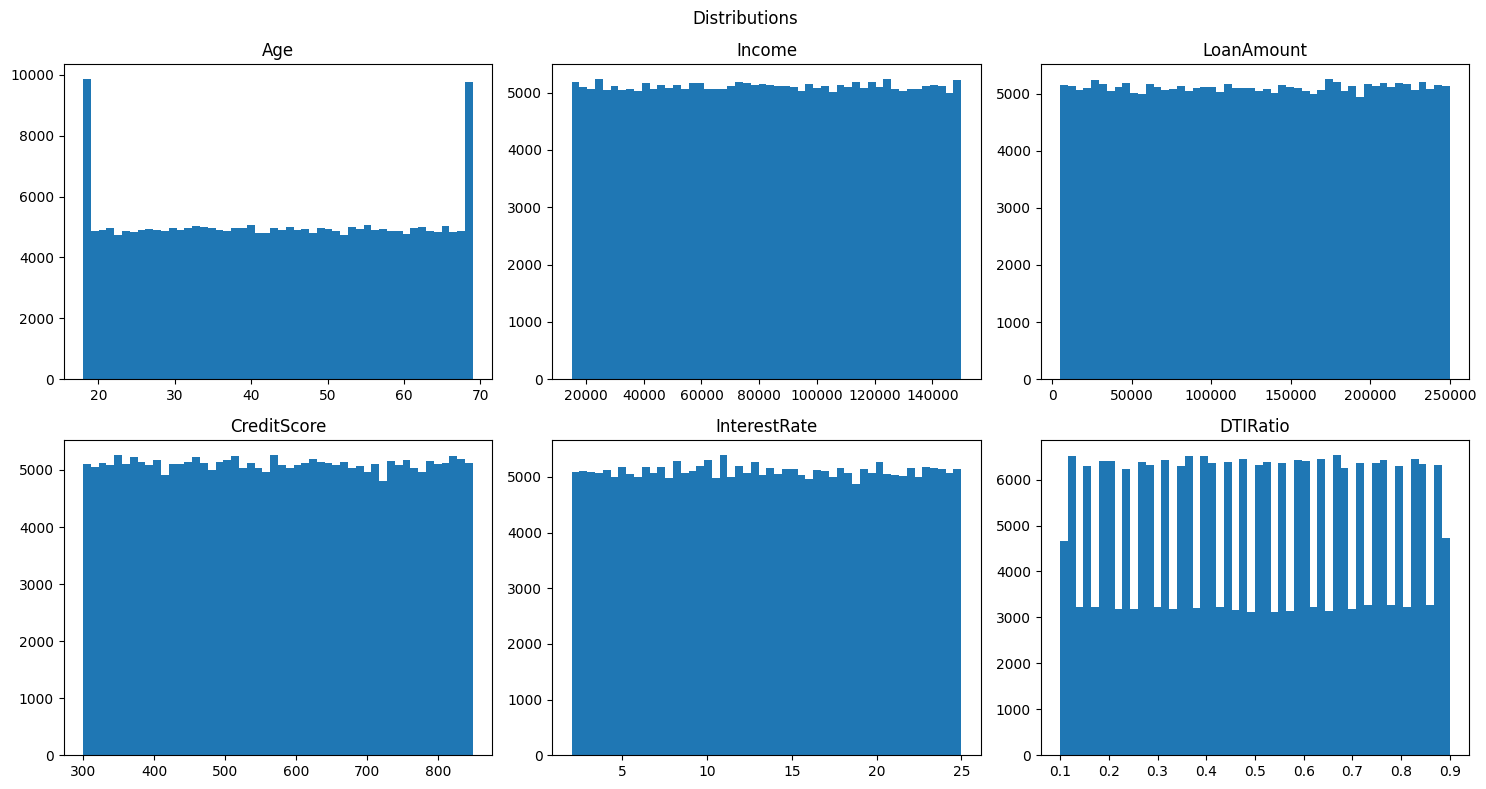

C:\Users\Swarnim\AppData\Local\Temp\ipykernel_30576\1756323153.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df.loc[df[TARGET] == 0, c], df.loc[df[TARGET] == 1, c]], vert=False, labels=['repaid', 'default'])
C:\Users\Swarnim\AppData\Local\Temp\ipykernel_30576\1756323153.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df.loc[df[TARGET] == 0, c], df.loc[df[TARGET] == 1, c]], vert=False, labels=['repaid', 'default'])
C:\Users\Swarnim\AppData\Local\Temp\ipykernel_30576\1756323153.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df.loc[df[TARGET] == 0, c], df.loc[df[TARGE

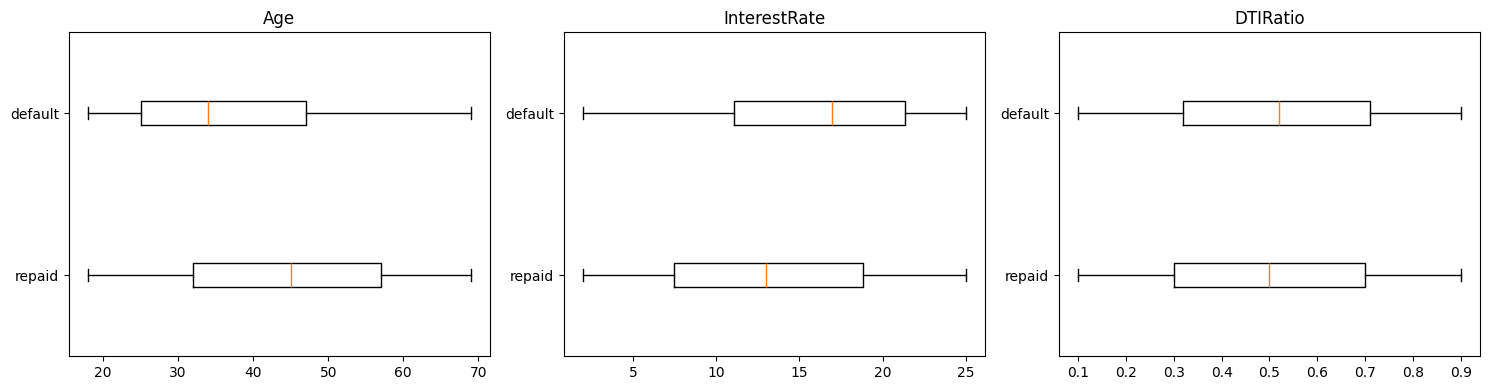

In [3]:
num = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines',
       'InterestRate', 'LoanTerm', 'DTIRatio']
print(df.groupby(TARGET)[num].median().round(2).to_string())
print('\nCorr with target:')
print(df[num + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False).round(4).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, ['Age', 'Income', 'LoanAmount', 'CreditScore', 'InterestRate', 'DTIRatio']):
    ax.hist(df[c], bins=50)
    ax.set_title(c)
fig.suptitle('Distributions')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes.flat, ['Age', 'InterestRate', 'DTIRatio']):
    ax.boxplot([df.loc[df[TARGET] == 0, c], df.loc[df[TARGET] == 1, c]], vert=False, labels=['repaid', 'default'])
    ax.set_title(c)
fig.tight_layout()
plt.show()

--- Education ---
               mean  count
Education                 
PhD          0.1059  63537
Master's     0.1087  63541
Bachelor's   0.1210  64366
High School  0.1288  63903
--- EmploymentType ---
                  mean  count
EmploymentType               
Full-time       0.0946  63656
Self-employed   0.1146  63706
Part-time       0.1197  64161
Unemployed      0.1355  63824
--- MaritalStatus ---
                 mean  count
MaritalStatus               
Married        0.1040  85302
Single         0.1191  85012
Divorced       0.1253  85033
--- HasMortgage ---
               mean   count
HasMortgage                
Yes          0.1088  127677
No           0.1235  127670
--- HasDependents ---
                 mean   count
HasDependents                
Yes            0.1050  127742
No             0.1272  127605
--- LoanPurpose ---
               mean  count
LoanPurpose               
Home         0.1023  51286
Other        0.1179  50914
Education    0.1184  51005
Auto         0.1188  

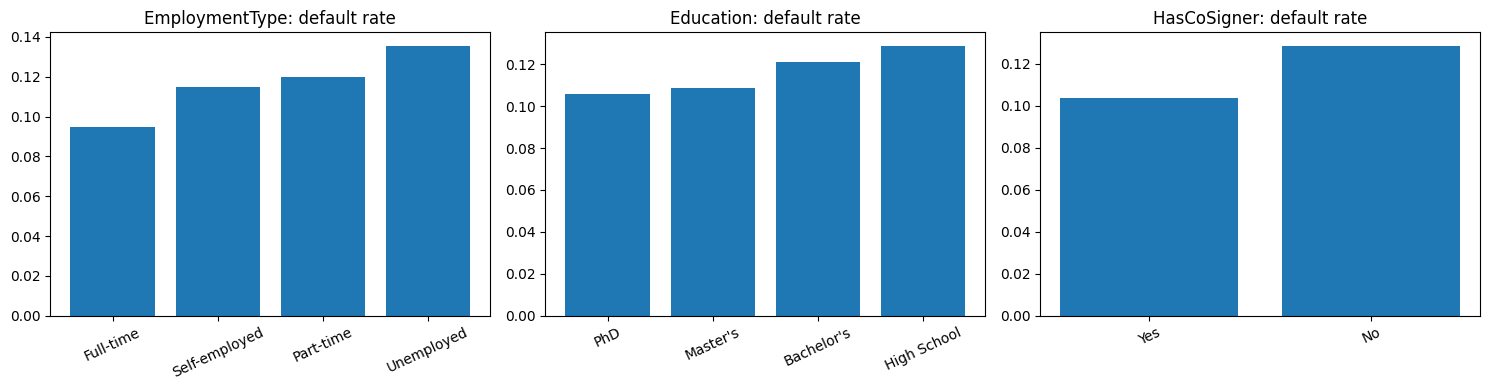

In [4]:
for c in ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']:
    t = df.groupby(c)[TARGET].agg(['mean', 'count']).round(4).sort_values('mean')
    print(f'--- {c} ---')
    print(t.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes.flat, ['EmploymentType', 'Education', 'HasCoSigner']):
    t = df.groupby(c)[TARGET].mean().sort_values()
    ax.bar(t.index.astype(str), t.values)
    ax.set_title(f'{c}: default rate')
    ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
plt.show()

## Feature engineering

`loan_to_income = LoanAmount / Income` (affordability burden; median 2.05 vs 1.50 by target, best single signal).
Income minimum is 15,000 here, so no zero-division — but `np.where` guards it anyway.
`income_is_zero` is skipped: this dataset has no zero incomes, so the flag would be a constant.

In [5]:
df['loan_to_income'] = np.where(df['Income'] > 0, df['LoanAmount'] / df['Income'], np.nan)
print('loan_to_income median by Default:')
print(df.groupby(TARGET)['loan_to_income'].median().round(3).to_string())
print('corr with target:', round(float(df[['loan_to_income', TARGET]].corr().loc['loan_to_income', TARGET]), 4))
print('NaN/inf created:', int(df['loan_to_income'].isna().sum()), '/', int(np.isinf(df['loan_to_income']).sum()))

loan_to_income median by Default:
Default
0    1.496
1    2.050
corr with target: 0.179
NaN/inf created: 0 / 0


## Train/test split (80/20, stratified) — before any preprocessing fitting

In [6]:
NUMERIC = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines',
           'InterestRate', 'LoanTerm', 'DTIRatio', 'loan_to_income']
ORDINAL = {'Education': ['High School', "Bachelor's", "Master's", 'PhD']}
NOMINAL = ['EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
FEATURES = NUMERIC + list(ORDINAL) + NOMINAL
print('Numeric:', NUMERIC, '\nOrdinal:', ORDINAL, '\nNominal:', NOMINAL)

X = df[FEATURES].copy()
y = df[TARGET].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Train %:', (y_train.value_counts(normalize=True) * 100).round(2).to_dict())
print('Test  %:', (y_test.value_counts(normalize=True) * 100).round(2).to_dict())

Numeric: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'loan_to_income'] 
Ordinal: {'Education': ['High School', "Bachelor's", "Master's", 'PhD']} 
Nominal: ['EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


Train: (204277, 17) | Test: (51070, 17)
Train %: {0: 88.39, 1: 11.61}
Test  %: {0: 88.39, 1: 11.61}


## Preprocessing pipelines (unfitted — Phase 3 fits them)

`Education` is genuinely ordered (default rate falls with each degree), so it gets `OrdinalEncoder`;
other categoricals are nominal → one-hot. Imputers are included for robustness even though this dataset has no missing values.

In [7]:
num_linear = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
num_tree = Pipeline([('imputer', SimpleImputer(strategy='median'))])
ord_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                       ('enc', OrdinalEncoder(categories=[ORDINAL['Education']]))])
nom_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                       ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

linear_preprocessor = ColumnTransformer([('num', num_linear, NUMERIC), ('ord', ord_pipe, list(ORDINAL)),
                                             ('nom', nom_pipe, NOMINAL)])
tree_preprocessor = ColumnTransformer([('num', num_tree, NUMERIC), ('ord', ord_pipe, list(ORDINAL)),
                                          ('nom', nom_pipe, NOMINAL)])
print('Preprocessors built (unfitted). Features:', len(FEATURES))

Preprocessors built (unfitted). Features: 17


## Sanity checks (fit on train only, via throwaway clones)

In [8]:
assert TARGET not in X.columns and 'LoanID' not in X.columns
assert set(FEATURES) | {'LoanID', TARGET} == set(df.columns), 'column partition incomplete'
assert len(X_train) + len(X_test) == len(df), 'row loss'
assert (df['Income'] > 0).all(), 'non-positive income breaks loan_to_income'
from sklearn.base import clone
for name, pre in [('linear', linear_preprocessor), ('tree', tree_preprocessor)]:
    fitted = clone(pre).fit(X_train)
    Tr, Te = fitted.transform(X_train), fitted.transform(X_test)
    assert not np.isnan(Tr).any() and not np.isnan(Te).any()
    print(f'{name}: train {Tr.shape} test {Te.shape}, no NaNs — OK')
print('Stratification drift:', round(abs(float(y_train.mean()) - float(y_test.mean())), 5))
print('Done: ready for Phase 3 modeling.')

linear: train (204277, 29) test (51070, 29), no NaNs — OK


tree: train (204277, 29) test (51070, 29), no NaNs — OK
Stratification drift: 1e-05
Done: ready for Phase 3 modeling.
